# LlamaFactory: Unified Efficient Fine-Tuning of 100+ Language Models

## Replication Study — Table 4 Pattern with TinyLlama-1.1B

This notebook is a partial replication of:

> Zheng et al. (2024). *LlamaFactory: Unified Efficient Fine-Tuning of 100+ Language Models.*

The original Table 4 compares full fine-tuning, freeze-tuning, GaLore, LoRA, and QLoRA on models ranging from 2B to 13B parameters (Gemma-2B, Llama2-7B, Llama2-13B) trained on the PubMed biomedical corpus on an NVIDIA A100 40 GB GPU. Here we keep the same experimental logic but use **TinyLlama-1.1B-Chat** on the **Alpaca GPT-4** instruction-following dataset, run on an **NVIDIA RTX 6000 Ada Generation** GPU.

The goal is not to reproduce the paper's absolute numbers — the model, dataset, and hardware all differ. Instead, we verify that the **qualitative patterns** hold:

- All five methods improve validation perplexity over the untrained baseline.
- LoRA is competitive with full-parameter methods (Full-FT, GaLore) while using significantly less memory.
- QLoRA matches LoRA's quality while further reducing memory through 4-bit NF4 quantization of the base model.
- Freeze-tuning is fast but less expressive, producing higher perplexity than LoRA and Full-FT.

We additionally contribute a **novel ablation** (Section 6) comparing LoRA and QLoRA at six training-set sizes (100 to 10 000 examples), which is not present in the original paper.


## 1. Environment Setup

This section prepares the runtime used by every experiment. We first verify the GPU, then install the packages needed for the five fine-tuning strategies:

- **`llamafactory`** — the unified training CLI; wraps HuggingFace Trainer and handles YAML-based configuration.
- **`bitsandbytes`** — 4-bit NF4 quantization backend, required for QLoRA.
- **`galore-torch`** — provides the GaLore optimizer, which projects gradients onto a low-rank subspace to reduce optimizer-state memory.
- **`matplotlib / seaborn / pandas`** — used only for post-training visualization, so they do not affect measured training metrics.

The global constants defined at the end of this section control the whole notebook:

| Constant | Value | Role |
|---|---|---|
| `MODEL_NAME` | TinyLlama-1.1B-Chat | Pre-trained model loaded for all conditions |
| `DATASET_NAME` | alpaca_gpt4_en | Instruction-following dataset (HuggingFace Hub) |
| `MAX_MAIN_SAMPLES` | 10 000 | Number of examples used in the main Table-4-style experiment |
| `DATA_SIZES` | [100, 500, …, 10 000] | Grid of dataset sizes for the LoRA/QLoRA ablation |
| `VAL_FRACTION` | 0.1 | Fraction of examples held out for validation |
| `RANDOM_SEED` | 42 | Seed for dataset splitting and model initialization |


In [ ]:
# Verify GPU availability and driver version
!nvidia-smi

Sun Jun  7 22:48:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 6000 Ada Gene...    Off |   00000000:55:00.0 Off |                  Off |
| 30%   54C    P5             71W /  300W |      36MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Core fine-tuning framework (includes HuggingFace Trainer integration)
!pip install "llamafactory[torch,metrics]>=0.9.0" --quiet

# 4-bit quantization backend (required for QLoRA)
!pip install bitsandbytes>=0.43.0 accelerate>=0.30.0 --quiet

# GaLore optimizer (Gradient Low-Rank Projection)
!pip install galore-torch --quiet

# Plotting and data utilities
!pip install matplotlib seaborn pandas --quiet

# Confirm LlamaFactory CLI is available
!llamafactory-cli version

----------------------------------------------------------
| Welcome to LLaMA Factory, version 0.9.5                |
|                                                        |
| Project page: https://github.com/hiyouga/LLaMA-Factory |
----------------------------------------------------------


In [ ]:
import os

# Create project directories.
for d in ("data", "results", "configs", "figures"):
    os.makedirs(d, exist_ok=True)

# LlamaFactory resolves dataset names through data/dataset_info.json.
# We keep the small local demo as a fallback, but the main experiment uses
# alpaca_gpt4_en from the Hugging Face Hub so that max_samples=10000 is real.
!wget -q https://raw.githubusercontent.com/hiyouga/LLaMA-Factory/main/data/dataset_info.json \
     -O data/dataset_info.json

!wget -q https://raw.githubusercontent.com/hiyouga/LLaMA-Factory/main/data/alpaca_en_demo.json \
     -O data/alpaca_en_demo.json

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_NAME = "alpaca_gpt4_en"      # Change to "alpaca_en_demo" for a very fast smoke test.
FALLBACK_DATA_PATH = "data/alpaca_en_demo.json"
MAX_MAIN_SAMPLES = 10000
DATA_SIZES = [100, 500, 1000, 2000, 5000, 10000]
VAL_FRACTION = 0.1
RANDOM_SEED = 42

print("Data setup complete:")
for f in sorted(os.listdir("data")):
    print(f"  {f}  ({os.path.getsize(f'data/{f}') / 1024:.0f} KB)")
print(f"\nMain dataset: {DATASET_NAME}")
print(f"Main experiment samples: {MAX_MAIN_SAMPLES}")
print(f"Ablation sizes: {DATA_SIZES}")

Data setup complete:
  alpaca_en_demo.json  (840 KB)
  dataset_info.json  (17 KB)

Main dataset: alpaca_gpt4_en
Main experiment samples: 10000
Ablation sizes: [100, 500, 1000, 2000, 5000, 10000]


In [ ]:
import json
import math
import time
import subprocess
import threading
import torch
import pandas as pd

# Disable Weights & Biases logging — no API key required
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE']     = 'disabled'

# This environment dict is passed to every subprocess.run call
# so that child processes also have wandb suppressed.
_NO_WANDB_ENV = {**os.environ, 'WANDB_DISABLED': 'true', 'WANDB_MODE': 'disabled'}

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch  : 2.7.1+cu126
CUDA     : True
GPU      : NVIDIA RTX 6000 Ada Generation
VRAM     : 50.9 GB


## 2. Configuration Files

Each experiment is fully defined by a YAML file consumed by `llamafactory-cli train`. Generating these files programmatically from Python keeps the comparison controlled: every method uses the same model, dataset, chat template, validation-split fraction, precision, logging frequency, and checkpoint-selection rule.

**Key design choices shared by all configs:**

- `template: zephyr` — TinyLlama-1.1B-Chat was trained with the Zephyr prompt format. Using the matching template is required both for correct training and for a valid baseline perplexity comparison.
- `load_best_model_at_end: true` with `metric_for_best_model: eval_loss` — the final tables report the **best** validation checkpoint, not blindly the last step. Small datasets can cause overfitting after a strong early checkpoint, so best-checkpoint selection is the scientifically correct reporting strategy.
- `save_total_limit: 1` — keeps only the best checkpoint on disk to avoid excessive storage use.

The main experiment uses `MAX_MAIN_SAMPLES = 10 000` examples. The ablation (Section 6) writes additional LoRA and QLoRA configs for 100, 500, 1 000, 2 000, 5 000, and 10 000 examples; the latter reuses the main-experiment run to avoid duplicate training.


In [ ]:
def write_config(filepath, config_str):
    """Serialize a YAML config string to disk."""
    with open(filepath, "w") as f:
        f.write(config_str)
    print(f"  written: {filepath}")


# Shared base template. Fields in braces are filled by each factory function.
# Important choices:
#   - template=zephyr matches TinyLlama-1.1B-Chat's chat format.
#   - load_best_model_at_end prevents the final table from reporting an overfit
#     last checkpoint when validation loss already started increasing.
#   - save_total_limit=1 keeps disk usage manageable while still preserving the
#     best checkpoint selected by eval_loss.
BASE_CONFIG = """### Model
model_name_or_path: {model_name}

### Task
stage: sft
do_train: true

### Dataset
dataset: {dataset_name}
template: zephyr
cutoff_len: 512
val_size: 0.1
preprocessing_num_workers: 4

### Training hyperparameters
per_device_train_batch_size: {batch_size}
gradient_accumulation_steps: {grad_accum}
learning_rate: {lr}
num_train_epochs: {epochs}
lr_scheduler_type: cosine
warmup_ratio: 0.1
seed: {seed}

### Precision
fp16: true

### Logging & Saving
logging_steps: {logging_steps}
save_strategy: steps
save_steps: {eval_steps}
save_total_limit: 1
overwrite_output_dir: true
report_to: none
plot_loss: true

### Evaluation
do_eval: true
per_device_eval_batch_size: 4
eval_strategy: steps
eval_steps: {eval_steps}
load_best_model_at_end: true
metric_for_best_model: eval_loss
greater_is_better: false
"""

In [ ]:
# ── LoRA ──────────────────────────────────────────────────────────────────────
# rank=64 is intentionally less aggressive than rank=128 on a 1-2k sample setup.
# The previous rank=128 / dropout=0.0 configuration fit the training split quickly
# but overfit the validation split. Dropout and best-checkpoint selection stabilize it.
def make_lora_config(max_samples, output_dir, batch_size=4, grad_accum=4,
                     lr="5.0e-5", epochs=2, logging_steps=5, eval_steps=25,
                     dataset_name=DATASET_NAME):
    config = BASE_CONFIG.format(
        model_name=MODEL_NAME, dataset_name=dataset_name, seed=RANDOM_SEED,
        batch_size=batch_size, grad_accum=grad_accum, lr=lr, epochs=epochs,
        logging_steps=logging_steps, eval_steps=eval_steps,
    )
    config += f"""
### Method: LoRA
finetuning_type: lora
lora_rank: 64
lora_alpha: 128
lora_dropout: 0.05
lora_target: q_proj,k_proj,v_proj,o_proj

max_samples: {max_samples}
output_dir: {output_dir}
"""
    return config


# ── QLoRA ─────────────────────────────────────────────────────────────────────
# Same adapter capacity as LoRA, but the frozen base model is loaded in 4-bit NF4.
# This should minimize memory while keeping perplexity close to LoRA.
def make_qlora_config(max_samples, output_dir, batch_size=4, grad_accum=4,
                      lr="5.0e-5", epochs=2, logging_steps=5, eval_steps=25,
                      dataset_name=DATASET_NAME):
    config = BASE_CONFIG.format(
        model_name=MODEL_NAME, dataset_name=dataset_name, seed=RANDOM_SEED,
        batch_size=batch_size, grad_accum=grad_accum, lr=lr, epochs=epochs,
        logging_steps=logging_steps, eval_steps=eval_steps,
    )
    config += f"""
### Method: QLoRA (4-bit NF4 quantization via bitsandbytes)
finetuning_type: lora
lora_rank: 64
lora_alpha: 128
lora_dropout: 0.05
lora_target: q_proj,k_proj,v_proj,o_proj
quantization_bit: 4
quantization_method: bitsandbytes

max_samples: {max_samples}
output_dir: {output_dir}
"""
    return config


# ── Freeze-tuning ─────────────────────────────────────────────────────────────
# Only the last transformer blocks are trainable; all earlier layers are frozen.
def make_freeze_config(max_samples, output_dir, batch_size=4, grad_accum=4,
                       lr="1.0e-5", epochs=3, logging_steps=5, eval_steps=25,
                       dataset_name=DATASET_NAME):
    config = BASE_CONFIG.format(
        model_name=MODEL_NAME, dataset_name=dataset_name, seed=RANDOM_SEED,
        batch_size=batch_size, grad_accum=grad_accum, lr=lr, epochs=epochs,
        logging_steps=logging_steps, eval_steps=eval_steps,
    )
    config += f"""
### Method: Freeze-tuning (last 4 transformer layers)
finetuning_type: freeze
freeze_trainable_layers: 4
freeze_trainable_modules: all

max_samples: {max_samples}
output_dir: {output_dir}
"""
    return config


# ── Full fine-tuning ──────────────────────────────────────────────────────────
# All parameters are updated. A smaller LR plus best-checkpoint selection avoids
# reporting the overfit final checkpoint on small validation sets.
def make_full_ft_config(max_samples, output_dir, batch_size=2, grad_accum=8,
                        lr="5.0e-6", epochs=2, logging_steps=5, eval_steps=25,
                        dataset_name=DATASET_NAME):
    config = BASE_CONFIG.format(
        model_name=MODEL_NAME, dataset_name=dataset_name, seed=RANDOM_SEED,
        batch_size=batch_size, grad_accum=grad_accum, lr=lr, epochs=epochs,
        logging_steps=logging_steps, eval_steps=eval_steps,
    )
    config += f"""
### Method: Full fine-tuning
finetuning_type: full

max_samples: {max_samples}
output_dir: {output_dir}
"""
    return config


# ── GaLore ────────────────────────────────────────────────────────────────────
# GaLore updates all parameters but projects gradients into a low-rank subspace,
# reducing optimizer-state memory while retaining much of full fine-tuning's capacity.
def make_galore_config(max_samples, output_dir, batch_size=2, grad_accum=8,
                       lr="5.0e-5", epochs=2, logging_steps=5, eval_steps=25,
                       dataset_name=DATASET_NAME):
    config = BASE_CONFIG.format(
        model_name=MODEL_NAME, dataset_name=dataset_name, seed=RANDOM_SEED,
        batch_size=batch_size, grad_accum=grad_accum, lr=lr, epochs=epochs,
        logging_steps=logging_steps, eval_steps=eval_steps,
    )
    config += f"""
### Method: GaLore (Gradient Low-Rank Projection)
finetuning_type: full
use_galore: true
galore_rank: 16
galore_update_interval: 200
galore_scale: 0.25
galore_proj_type: std

# adamw_torch is required because fused AdamW is incompatible with GaLore hooks.
optim: adamw_torch

max_samples: {max_samples}
output_dir: {output_dir}
"""
    return config

In [ ]:
MAIN_SUFFIX = str(MAX_MAIN_SAMPLES)

print(f"Writing main experiment configs ({MAX_MAIN_SAMPLES} examples) ...")
write_config(f"configs/lora_{MAIN_SUFFIX}.yaml",
             make_lora_config(MAX_MAIN_SAMPLES, f"results/lora_{MAIN_SUFFIX}",
                              logging_steps=25, eval_steps=100))
write_config(f"configs/qlora_{MAIN_SUFFIX}.yaml",
             make_qlora_config(MAX_MAIN_SAMPLES, f"results/qlora_{MAIN_SUFFIX}",
                               logging_steps=25, eval_steps=100))
write_config(f"configs/freeze_{MAIN_SUFFIX}.yaml",
             make_freeze_config(MAX_MAIN_SAMPLES, f"results/freeze_{MAIN_SUFFIX}",
                                logging_steps=25, eval_steps=100))
write_config(f"configs/full_ft_{MAIN_SUFFIX}.yaml",
             make_full_ft_config(MAX_MAIN_SAMPLES, f"results/full_ft_{MAIN_SUFFIX}",
                                 logging_steps=25, eval_steps=100))
write_config(f"configs/galore_{MAIN_SUFFIX}.yaml",
             make_galore_config(MAX_MAIN_SAMPLES, f"results/galore_{MAIN_SUFFIX}",
                                logging_steps=25, eval_steps=100))

print("\nWriting ablation configs (LoRA & QLoRA across all data sizes) ...")
for n in DATA_SIZES:
    if n == MAX_MAIN_SAMPLES:
        # Keep the 10000-example LoRA/QLoRA configs aligned with the main run.
        log_steps = 25
        eval_steps = 100
    else:
        log_steps = max(2, n // 50)
        eval_steps = max(5, n // 20)
    epochs = 3 if n <= 500 else 2
    write_config(f"configs/lora_{n}.yaml",
                 make_lora_config(n, f"results/lora_{n}", epochs=epochs,
                                  logging_steps=log_steps, eval_steps=eval_steps))
    write_config(f"configs/qlora_{n}.yaml",
                 make_qlora_config(n, f"results/qlora_{n}", epochs=epochs,
                                   logging_steps=log_steps, eval_steps=eval_steps))

print("\nAll configs written.")

Writing main experiment configs (10000 examples) ...
  written: configs/lora_10000.yaml
  written: configs/qlora_10000.yaml
  written: configs/freeze_10000.yaml
  written: configs/full_ft_10000.yaml
  written: configs/galore_10000.yaml

Writing ablation configs (LoRA & QLoRA across all data sizes) ...
  written: configs/lora_100.yaml
  written: configs/qlora_100.yaml
  written: configs/lora_500.yaml
  written: configs/qlora_500.yaml
  written: configs/lora_1000.yaml
  written: configs/qlora_1000.yaml
  written: configs/lora_2000.yaml
  written: configs/qlora_2000.yaml
  written: configs/lora_5000.yaml
  written: configs/qlora_5000.yaml
  written: configs/lora_10000.yaml
  written: configs/qlora_10000.yaml

All configs written.


## 3. Helper Utilities

This section contains reusable measurement and parsing code shared by all training loops.

- **`GPUMonitor`** — samples `nvidia-smi` in a background thread throughout each training subprocess to record the peak GPU memory allocation.
- **`parse_trainer_state`** — reads `trainer_state.json`, `eval_results.json`, and `train_results.json` from the checkpoint directory. It returns the **best** validation loss (`best_eval_loss`) preferred by `load_best_model_at_end`, not just the last evaluation value.
- **`parse_trainable_params`** — extracts the trainable-parameter count that LlamaFactory prints at the start of each run, so the final table can include it without hard-coding it.
- **`run_experiment`** — wraps the full lifecycle: starts the GPU monitor, runs `llamafactory-cli train` as a subprocess, stops the monitor, parses all output files, estimates token throughput, and returns a single standardized result dictionary used by Sections 7 and 8.

Centralizing this logic ensures that every method is measured and reported under identical conditions.


In [ ]:
class GPUMonitor:
    """
    Background thread that polls `nvidia-smi` at a fixed interval and records
    the peak GPU memory used (in MB) during a training run.

    Usage:
        monitor = GPUMonitor(interval=1.0)
        monitor.start()
        # ... run training ...
        peak_gb = monitor.stop()   # returns peak memory in GB
    """

    def __init__(self, interval=0.5):
        self.interval        = interval
        self.peak_memory_mb  = 0
        self.running         = False
        self._thread         = None

    def _monitor(self):
        while self.running:
            try:
                result = subprocess.run(
                    ["nvidia-smi", "--query-gpu=memory.used",
                     "--format=csv,noheader,nounits"],
                    capture_output=True, text=True
                )
                mem_mb = int(result.stdout.strip().split("\n")[0])
                self.peak_memory_mb = max(self.peak_memory_mb, mem_mb)
            except (ValueError, IndexError):
                pass
            time.sleep(self.interval)

    def start(self):
        self.peak_memory_mb = 0
        self.running        = True
        self._thread        = threading.Thread(target=self._monitor, daemon=True)
        self._thread.start()

    def stop(self):
        self.running = False
        if self._thread:
            self._thread.join(timeout=2)
        return self.peak_memory_mb / 1024   # MB → GB

In [ ]:
def parse_trainer_state(output_dir):
    """
    Parse HuggingFace Trainer logs and final evaluation files.

    The notebook reports the best validation checkpoint, not necessarily the last
    step. This is important for small-data fine-tuning because validation loss can
    rise after the model has already reached its best generalization point.
    """
    state_path = os.path.join(output_dir, "trainer_state.json")
    eval_path = os.path.join(output_dir, "eval_results.json")
    train_path = os.path.join(output_dir, "train_results.json")

    if not os.path.exists(state_path):
        print(f"  Warning: {state_path} not found")
        return {}

    with open(state_path) as f:
        state = json.load(f)

    train_losses, eval_losses = [], []
    for entry in state.get("log_history", []):
        if "loss" in entry and "eval_loss" not in entry:
            train_losses.append({
                "step": entry["step"],
                "loss": entry["loss"],
                "epoch": entry.get("epoch", 0),
            })
        if "eval_loss" in entry:
            eval_losses.append({
                "step": entry["step"],
                "eval_loss": entry["eval_loss"],
                "epoch": entry.get("epoch", 0),
            })

    eval_file_loss = None
    if os.path.exists(eval_path):
        with open(eval_path) as f:
            eval_file_loss = json.load(f).get("eval_loss")

    train_file_loss = None
    if os.path.exists(train_path):
        with open(train_path) as f:
            train_file_loss = json.load(f).get("train_loss")

    best_eval = min(eval_losses, key=lambda x: x["eval_loss"]) if eval_losses else None
    final_eval_loss = eval_losses[-1]["eval_loss"] if eval_losses else eval_file_loss
    selected_eval_loss = (state.get("best_metric") or
                          (best_eval["eval_loss"] if best_eval else None) or
                          final_eval_loss)

    return {
        "train_losses": train_losses,
        "eval_losses": eval_losses,
        "final_train_loss": train_file_loss or (train_losses[-1]["loss"] if train_losses else None),
        "final_eval_loss": final_eval_loss,
        "best_eval_loss": selected_eval_loss,
        "best_eval_step": state.get("best_model_checkpoint") or (best_eval["step"] if best_eval else None),
        "total_steps": state.get("global_step", 0),
    }

In [ ]:
import re


def parse_trainable_params(stdout):
    """Extract the trainable-parameter count from LlamaFactory logs when present."""
    patterns = [
        r"trainable params:\s*([0-9,]+)",
        r"trainable_params\s*=\s*([0-9,]+)",
    ]
    for pattern in patterns:
        match = re.search(pattern, stdout, flags=re.IGNORECASE)
        if match:
            return int(match.group(1).replace(",", ""))
    return None


def run_experiment(method_name, config_path, output_dir, n_train=MAX_MAIN_SAMPLES):
    """
    Execute one training run via `llamafactory-cli train`, track peak GPU memory,
    and return standardized metrics. Evaluation quality is reported from the best
    validation checkpoint selected by eval_loss.
    """
    print(f"\n{'='*60}")
    print(f"  TRAINING: {method_name}")
    print(f"{'='*60}")

    monitor = GPUMonitor(interval=1.0)
    monitor.start()

    start_time = time.time()
    result = subprocess.run(
        ["llamafactory-cli", "train", config_path],
        capture_output=True, text=True,
        env=_NO_WANDB_ENV,
    )
    elapsed = time.time() - start_time

    peak_mem_gb = monitor.stop()

    if result.returncode != 0:
        print(f"  FAILED: {method_name}")
        print(result.stderr[-1500:])
        return {"status": "FAILED", "error": result.stderr[-500:]}

    metrics = parse_trainer_state(output_dir)
    selected_eval_loss = metrics.get("best_eval_loss") or metrics.get("final_eval_loss")

    # Prefer Trainer's measured runtime when available; fall back to wall-clock time.
    train_results_path = os.path.join(output_dir, "train_results.json")
    measured_runtime = None
    if os.path.exists(train_results_path):
        with open(train_results_path) as f:
            measured_runtime = json.load(f).get("train_runtime")
    runtime_for_throughput = measured_runtime or elapsed

    # Estimate token throughput from configured epochs so Freeze (3 epochs) is not
    # compared as if it ran for the 2-epoch LoRA/Full/GaLore schedule.
    configured_epochs = 2
    try:
        import yaml
        with open(config_path) as f:
            configured_epochs = float(yaml.safe_load(f).get("num_train_epochs", configured_epochs))
    except Exception:
        pass

    n_train_eff = n_train * (1 - VAL_FRACTION)
    approx_toks = n_train_eff * configured_epochs * 512
    throughput = approx_toks / runtime_for_throughput if runtime_for_throughput else 0

    ppl = round(math.exp(selected_eval_loss), 2) if selected_eval_loss else None
    trainable_params = parse_trainable_params(result.stdout)

    res = {
        "status": "OK",
        "peak_memory_gb": peak_mem_gb,
        "elapsed_time_s": elapsed,
        "throughput_tokens_per_s": throughput,
        "trainable_params": trainable_params,
        "final_train_loss": metrics.get("final_train_loss"),
        "final_eval_loss": metrics.get("final_eval_loss"),
        "best_eval_loss": selected_eval_loss,
        "best_eval_step": metrics.get("best_eval_step"),
        "total_steps": metrics.get("total_steps"),
        "train_losses": metrics.get("train_losses", []),
        "eval_losses": metrics.get("eval_losses", []),
        "perplexity": ppl,
    }

    print(f"  Peak memory  : {peak_mem_gb:.2f} GB")
    print(f"  Elapsed      : {elapsed:.1f} s")
    print(f"  Throughput   : ~{throughput:.0f} tokens/s")
    print(f"  Train loss   : {metrics.get('final_train_loss', 'N/A')}")
    print(f"  Best eval    : {selected_eval_loss} @ {metrics.get('best_eval_step')}")
    print(f"  Final eval   : {metrics.get('final_eval_loss', 'N/A')}")
    print(f"  Perplexity   : {ppl}")

    torch.cuda.empty_cache()
    time.sleep(5)
    return res

## 4. Baseline — Zero-Shot Perplexity of the Pre-trained Model

Before any fine-tuning, we measure how well TinyLlama-1.1B-Chat predicts assistant responses on the same validation split used during training. This value is the **Baseline PPL** in Table 1 and the horizontal reference line in Figure 4.

A naive perplexity calculation on a pre-trained chat model can give absurdly high values (we observed ≈ 90 000 with a first attempt). Three corrections are required to obtain a meaningful number:

1. **Padding masking** — batch padding tokens must be excluded from the loss with `labels[attention_mask == 0] = -100`, otherwise their unpredictable cross-entropy dominates the average.
2. **Correct chat template** — TinyLlama-1.1B-Chat expects the Zephyr format. Using the Alpaca `### Instruction:` markers instead confronts the model with sequences it has never seen during pre-training, artificially inflating the loss.
3. **Response-only loss** — LlamaFactory's SFT data collator masks instruction tokens so the loss is computed only on the assistant reply. We replicate this by tokenizing the prompt-only prefix to determine where the response begins, then setting `labels[:, :prompt_len] = -100` for each sample.

After these three corrections, the baseline perplexity is **3.51**, a realistic zero-shot instruction-following score for a 1.1B chat model.


In [ ]:
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer


def load_instruction_records(dataset_name=DATASET_NAME, max_samples=MAX_MAIN_SAMPLES):
    """Load records in Alpaca format for the baseline perplexity computation."""
    if dataset_name == "alpaca_en_demo":
        with open(FALLBACK_DATA_PATH) as f:
            records = json.load(f)
    else:
        # LlamaFactory's registry points alpaca_gpt4_en/alpaca_en to HF datasets.
        ds = load_dataset(f"llamafactory/{dataset_name}", split="train")
        records = [dict(x) for x in ds]
    return records[:max_samples]


def compute_baseline_ppl(
    model_name=MODEL_NAME,
    dataset_name=DATASET_NAME,
    val_fraction=VAL_FRACTION,
    max_samples=MAX_MAIN_SAMPLES,
    max_len=512,
    batch_size=4,
    seed=RANDOM_SEED,
):
    """Compute response-only perplexity for the pre-trained model.

    The validation split mirrors LlamaFactory's seeded train/test split, and the
    Zephyr chat template matches the TinyLlama-1.1B-Chat formatting used in the
    YAML configs.
    """
    print("Loading tokenizer and model in fp16 ...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()

    raw = load_instruction_records(dataset_name=dataset_name, max_samples=max_samples)
    # Use datasets.Dataset for a deterministic split matching Trainer semantics.
    from datasets import Dataset
    val = Dataset.from_list(raw).train_test_split(
        test_size=val_fraction, seed=seed, shuffle=True
    )["test"]
    print(f"Evaluating on {len(val)} validation samples from {dataset_name} ...")

    SYSTEM_PROMPT = "You are Zephyr, a helpful assistant."

    def build_messages(item):
        instruction = item.get("instruction", "")
        inp = item.get("input", "")
        user_text = f"{instruction}\n{inp}".strip() if inp else instruction
        return [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_text},
            {"role": "assistant", "content": item.get("output", "")},
        ]

    device = next(model.parameters()).device
    total_loss, total_count = 0.0, 0

    with torch.no_grad():
        for i in range(0, len(val), batch_size):
            # HuggingFace Dataset slicing returns a dict of columns, so we
            # convert that column batch back into a list of example dicts.
            batch = val[i : i + batch_size]
            batch_items = [
                {key: values[j] for key, values in batch.items()}
                for j in range(len(next(iter(batch.values()))))
            ]

            full_texts = [
                tokenizer.apply_chat_template(
                    build_messages(item), tokenize=False, add_generation_prompt=False
                )
                for item in batch_items
            ]
            prompt_only_texts = [
                tokenizer.apply_chat_template(
                    build_messages(item)[:-1], tokenize=False, add_generation_prompt=True
                )
                for item in batch_items
            ]

            full_enc = tokenizer(
                full_texts, return_tensors="pt", padding=True,
                truncation=True, max_length=max_len,
            )
            prompt_enc = tokenizer(
                prompt_only_texts, return_tensors=None, truncation=True,
                max_length=max_len, add_special_tokens=False,
            )

            input_ids = full_enc["input_ids"].to(device)
            attn_mask = full_enc["attention_mask"].to(device)
            labels = input_ids.clone()
            labels[attn_mask == 0] = -100

            for j, prompt_ids in enumerate(prompt_enc["input_ids"]):
                labels[j, :len(prompt_ids)] = -100

            outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
            valid_tokens = (labels != -100).sum().item()
            if valid_tokens > 0:
                total_loss += outputs.loss.item() * valid_tokens
                total_count += valid_tokens

    ppl = math.exp(total_loss / total_count)
    print(f"\nBaseline perplexity (pre-trained, no fine-tuning): {ppl:.4f}")

    del model
    torch.cuda.empty_cache()
    return ppl


baseline_ppl = compute_baseline_ppl()

/home/sepanta/NLP/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tokenizer and model in fp16 ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 988.82it/s]


Evaluating on 1000 validation samples from alpaca_gpt4_en ...

Baseline perplexity (pre-trained, no fine-tuning): 3.5149


## 5. Main Experiment — All Methods at 10 000 Examples

This section reproduces the structure of Table 4 on TinyLlama-1.1B. Every method is trained on `MAX_MAIN_SAMPLES = 10 000` Alpaca GPT-4 examples and evaluated on the same 10% held-out validation split.

The NVIDIA RTX 6000 Ada has enough VRAM (≈ 50.9 GB) for TinyLlama full fine-tuning. The main practical cost of 10 000 examples is **runtime** rather than memory: peak GPU memory is controlled by the method (adapter size, quantization), precision, batch size, and sequence length.

All results are stored in `main_results`. The visualization cells in Section 7 and the final tables in Section 8 read from this dictionary, so **Figures 1, 3, and 4** and **Table 1** all reflect this 10 000-example experiment.


In [ ]:
# Training order follows the paper's table for readability.
MAIN_SUFFIX = str(MAX_MAIN_SAMPLES)
MAIN_CONFIGS = {
    "Full-FT": (f"configs/full_ft_{MAIN_SUFFIX}.yaml", f"results/full_ft_{MAIN_SUFFIX}"),
    "Freeze":  (f"configs/freeze_{MAIN_SUFFIX}.yaml",  f"results/freeze_{MAIN_SUFFIX}"),
    "GaLore":  (f"configs/galore_{MAIN_SUFFIX}.yaml",  f"results/galore_{MAIN_SUFFIX}"),
    "LoRA":    (f"configs/lora_{MAIN_SUFFIX}.yaml",    f"results/lora_{MAIN_SUFFIX}"),
    "QLoRA":   (f"configs/qlora_{MAIN_SUFFIX}.yaml",   f"results/qlora_{MAIN_SUFFIX}"),
}

main_results = {}

for method_name, (config_path, output_dir) in MAIN_CONFIGS.items():
    main_results[method_name] = run_experiment(
        method_name, config_path, output_dir, n_train=MAX_MAIN_SAMPLES
    )


  TRAINING: Full-FT


  Peak memory  : 24.35 GB
  Elapsed      : 1353.2 s
  Throughput   : ~6981 tokens/s
  Train loss   : 0.9935486741218431
  Best eval    : 1.1092592477798462 @ results/full_ft_10000/checkpoint-500
  Final eval   : 1.121904730796814
  Perplexity   : 3.03

  TRAINING: Freeze
  Peak memory  : 9.81 GB
  Elapsed      : 850.1 s
  Throughput   : ~16836 tokens/s
  Train loss   : 1.0339421627435408
  Best eval    : 1.1344377994537354 @ results/freeze_10000/checkpoint-1100
  Final eval   : 1.1388471126556396
  Perplexity   : 3.11

  TRAINING: GaLore
  Peak memory  : 22.04 GB
  Elapsed      : 1380.0 s
  Throughput   : ~6838 tokens/s
  Train loss   : 1.0415898936256422
  Best eval    : 1.1226874589920044 @ results/galore_10000/checkpoint-1126
  Final eval   : 1.1226874589920044
  Perplexity   : 3.07

  TRAINING: LoRA
  Peak memory  : 8.02 GB
  Elapsed      : 908.3 s
  Throughput   : ~10440 tokens/s
  Train loss   : 1.096194228736376
  Best eval    : 1.1170320510864258 @ results/lora_10000/checkpoint

In [ ]:
# Persist main results (excluding per-step histories for compactness).
summary = {
    k: {key: val for key, val in v.items()
        if key not in ("train_losses", "eval_losses")}
    for k, v in main_results.items()
}
with open("results/main_experiment_results.json", "w") as f:
    json.dump(summary, f, indent=2)

# Print summary — Baseline appears first as a reference row.
print("\nMain Experiment Summary")
print("=" * 98)
print(f"{'Method':<12} {'Trainable':<14} {'Memory (GB)':<14} {'Time (s)':<12} "
      f"{'Throughput':<16} {'Best Eval':<12} {'PPL'}")
print("-" * 98)
print(f"{'Baseline':<12} {'/':<14} {'/':<14} {'/':<12} {'/':<16} {'/':<12} {baseline_ppl:.2f}")

for method in ["Full-FT", "Freeze", "GaLore", "LoRA", "QLoRA"]:
    res = main_results.get(method, {})
    if res.get("status") == "OK":
        trainable = f"{res['trainable_params']:,}" if res.get("trainable_params") else "logged"
        print(f"{method:<12} {trainable:<14} {res['peak_memory_gb']:<14.2f} "
              f"{res['elapsed_time_s']:<12.1f} "
              f"{res['throughput_tokens_per_s']:<16.0f} "
              f"{str(res.get('best_eval_loss') or 'N/A'):<12} "
              f"{res.get('perplexity') or 'N/A'}")
    else:
        print(f"{method:<12} FAILED / OOM")


Main Experiment Summary
Method       Trainable      Memory (GB)    Time (s)     Throughput       Best Eval    PPL
--------------------------------------------------------------------------------------------------
Baseline     /              /              /            /                /            3.51
Full-FT      1,100,048,384  24.35          1353.2       6981             1.1092592477798462 3.03
Freeze       176,177,152    9.81           850.1        16836            1.1344377994537354 3.11
GaLore       1,100,048,384  22.04          1380.0       6838             1.1226874589920044 3.07
LoRA         18,022,400     8.02           908.3        10440            1.1170320510864258 3.06
QLoRA        18,022,400     8.02           907.2        10454            1.1170419454574585 3.06


## 6. Novel Ablation — LoRA vs. QLoRA Across Training Data Sizes

This ablation is our original contribution, not present in the original LlamaFactory paper.

**Scientific question:** Does 4-bit NF4 quantization (QLoRA) hurt more when training data is scarce? The intuition is that with fewer gradient updates, the model has less opportunity to compensate for quantization noise, potentially widening the gap between LoRA and QLoRA.

We train both methods at six dataset scales: **100, 500, 1 000, 2 000, 5 000, and 10 000** examples. The 10 000-example results are reused from Section 5 to avoid redundant computation.

All reported losses are **best validation losses**, consistent with the main table. Figure 2 (Section 7) visualizes these results with a log-scale x-axis so all six sizes are readable simultaneously.


In [ ]:
ablation_results = {"LoRA": {}, "QLoRA": {}}

for n in DATA_SIZES:
    for method, key in [("LoRA", "lora"), ("QLoRA", "qlora")]:

        # The main LoRA/QLoRA run is already completed — reuse its metrics.
        if n == MAX_MAIN_SAMPLES and method in main_results:
            ablation_results[method][n] = {
                "final_eval_loss": main_results[method].get("final_eval_loss"),
                "best_eval_loss": main_results[method].get("best_eval_loss"),
                "final_train_loss": main_results[method].get("final_train_loss"),
                "perplexity": main_results[method].get("perplexity"),
                "train_losses": main_results[method].get("train_losses", []),
                "eval_losses": main_results[method].get("eval_losses", []),
            }
            print(f"  {method} @ {n}: reusing main experiment results")
            continue

        config_path = f"configs/{key}_{n}.yaml"
        output_dir = f"results/{key}_{n}"
        print(f"\n  Running {method} @ {n} examples ...")

        result = subprocess.run(
            ["llamafactory-cli", "train", config_path],
            capture_output=True, text=True,
            env=_NO_WANDB_ENV,
        )

        if result.returncode != 0:
            print(f"  FAILED: {method} @ {n}")
            print(result.stderr[-1200:])
            ablation_results[method][n] = {"status": "FAILED"}
            continue

        metrics = parse_trainer_state(output_dir)
        selected_eval_loss = metrics.get("best_eval_loss") or metrics.get("final_eval_loss")
        ppl = round(math.exp(selected_eval_loss), 2) if selected_eval_loss else None

        ablation_results[method][n] = {
            "final_eval_loss": metrics.get("final_eval_loss"),
            "best_eval_loss": selected_eval_loss,
            "final_train_loss": metrics.get("final_train_loss"),
            "perplexity": ppl,
            "train_losses": metrics.get("train_losses", []),
            "eval_losses": metrics.get("eval_losses", []),
        }
        print(f"    Best eval loss: {selected_eval_loss}")
        torch.cuda.empty_cache()
        time.sleep(3)


  Running LoRA @ 100 examples ...
    Best eval loss: 1.158405065536499

  Running QLoRA @ 100 examples ...
    Best eval loss: 1.158141016960144

  Running LoRA @ 500 examples ...
    Best eval loss: 1.186835765838623

  Running QLoRA @ 500 examples ...
    Best eval loss: 1.1868431568145752

  Running LoRA @ 1000 examples ...
    Best eval loss: 1.115378737449646

  Running QLoRA @ 1000 examples ...
    Best eval loss: 1.1153923273086548

  Running LoRA @ 2000 examples ...
    Best eval loss: 1.0743043422698975

  Running QLoRA @ 2000 examples ...
    Best eval loss: 1.0743156671524048

  Running LoRA @ 5000 examples ...
    Best eval loss: 1.108578085899353

  Running QLoRA @ 5000 examples ...
    Best eval loss: 1.1085964441299438
  LoRA @ 10000: reusing main experiment results
  QLoRA @ 10000: reusing main experiment results


In [ ]:
# Persist ablation results to disk.
# We store compact summaries without per-step histories so the JSON stays easy to inspect.
ablation_summary = {
    method: {
        str(n): {k: v for k, v in res.items()
                 if k not in ("train_losses", "eval_losses")}
        for n, res in ablation_results[method].items()
    }
    for method in ablation_results
}
with open("results/ablation_results.json", "w") as f:
    json.dump(ablation_summary, f, indent=2)

# Print ablation summary table using the same metric as the plots and final table:
# best validation loss, not the last evaluation loss.
print("\nAblation: LoRA vs. QLoRA — Effect of Training Data Size")
print("=" * 72)
print(f"{'Examples':<12} {'LoRA Loss':<14} {'LoRA PPL':<12} "
      f"{'QLoRA Loss':<14} {'QLoRA PPL':<12} {'Gap (Q-L)'}")
print("-" * 72)

for n in DATA_SIZES:
    ll = ablation_results["LoRA"].get(n,  {}).get("best_eval_loss")
    ql = ablation_results["QLoRA"].get(n, {}).get("best_eval_loss")
    lp  = f"{math.exp(ll):.2f}" if ll else "N/A"
    qp  = f"{math.exp(ql):.2f}" if ql else "N/A"
    gap = f"{ql - ll:+.4f}"     if (ll and ql) else "N/A"
    print(f"{n:<12} {str(ll or 'N/A'):<14} {lp:<12} "
          f"{str(ql or 'N/A'):<14} {qp:<12} {gap}")


Ablation: LoRA vs. QLoRA — Effect of Training Data Size
Examples     LoRA Loss      LoRA PPL     QLoRA Loss     QLoRA PPL    Gap (Q-L)
------------------------------------------------------------------------
100          1.158405065536499 3.18         1.158141016960144 3.18         -0.0003
500          1.186835765838623 3.28         1.1868431568145752 3.28         +0.0000
1000         1.115378737449646 3.05         1.1153923273086548 3.05         +0.0000
2000         1.0743043422698975 2.93         1.0743156671524048 2.93         +0.0000
5000         1.108578085899353 3.03         1.1085964441299438 3.03         +0.0000
10000        1.1170320510864258 3.06         1.1170419454574585 3.06         +0.0000


## 7. Visualizations

The four figures summarize the results already computed in Sections 5 and 6. **No retraining happens here.**

The first code cell (Section 7 setup) reloads the compact JSON summaries from disk if the training dictionaries are not currently in memory. This means Section 7 can be run independently in a fresh kernel after training has already finished.

| Figure | Data source | What it shows |
|---|---|---|
| **Figure 1** | `main_results` (Section 5) | Peak GPU memory by method at 10 000 examples |
| **Figure 2** | `ablation_results` (Section 6) | LoRA vs. QLoRA best eval loss across all dataset sizes |
| **Figure 3** | `main_results` (requires in-memory histories) | Training loss curves over steps for all five methods |
| **Figure 4** | `main_results` (Section 5) | Combined memory / throughput / perplexity overview |

The color palette is consistent across all figures: the same color always represents the same method.


In [ ]:
import os
import json
import math
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

try:
    import torch
except ImportError:
    torch = None

matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['font.size']  = 11
plt.style.use('seaborn-v0_8-paper')

# Robust defaults for running Section 7 independently after training.
MAX_MAIN_SAMPLES = globals().get("MAX_MAIN_SAMPLES", 10000)
DATA_SIZES = globals().get("DATA_SIZES", [100, 500, 1000, 2000, 5000, 10000])

# If the training dictionaries are not currently in memory, reload their compact
# JSON summaries. This fixes NameError issues when only the plotting section is run.
if "main_results" not in globals() and os.path.exists("results/main_experiment_results.json"):
    with open("results/main_experiment_results.json") as f:
        main_results = json.load(f)

if "ablation_results" not in globals() and os.path.exists("results/ablation_results.json"):
    with open("results/ablation_results.json") as f:
        loaded_ablation = json.load(f)
    ablation_results = {
        method: {int(n): res for n, res in sizes.items()}
        for method, sizes in loaded_ablation.items()
    }

# Baseline perplexity is available only if Section 4 was run in this kernel.
# Figure 4 skips the baseline line when the value is not in memory.
baseline_ppl = globals().get("baseline_ppl", None)

# Consistent color palette across all figures.
# The same color always represents the same method to make cross-figure reading easier.
COLORS = {
    "Full-FT": "#e74c3c",
    "Freeze":  "#f39c12",
    "GaLore":  "#9b59b6",
    "LoRA":    "#2ecc71",
    "QLoRA":   "#3498db",
}

# Use the actual project hardware label explicitly. This avoids stale labels if the
# notebook is opened on a machine where torch/CUDA is not initialized.
GPU_LABEL = "NVIDIA RTX 6000 Ada Generation"
if torch is not None and torch.cuda.is_available():
    detected_gpu = torch.cuda.get_device_name(0)
    if "RTX 6000" in detected_gpu or "6000 Ada" in detected_gpu:
        GPU_LABEL = detected_gpu

MAIN_EXPERIMENT_LABEL = f"TinyLlama-1.1B · {MAX_MAIN_SAMPLES} examples · {GPU_LABEL}"

print(f"Plot context: {MAIN_EXPERIMENT_LABEL}")
print(f"Ablation sizes: {DATA_SIZES}")

Plot context: TinyLlama-1.1B · 10000 examples · NVIDIA RTX 6000 Ada Generation
Ablation sizes: [100, 500, 1000, 2000, 5000, 10000]


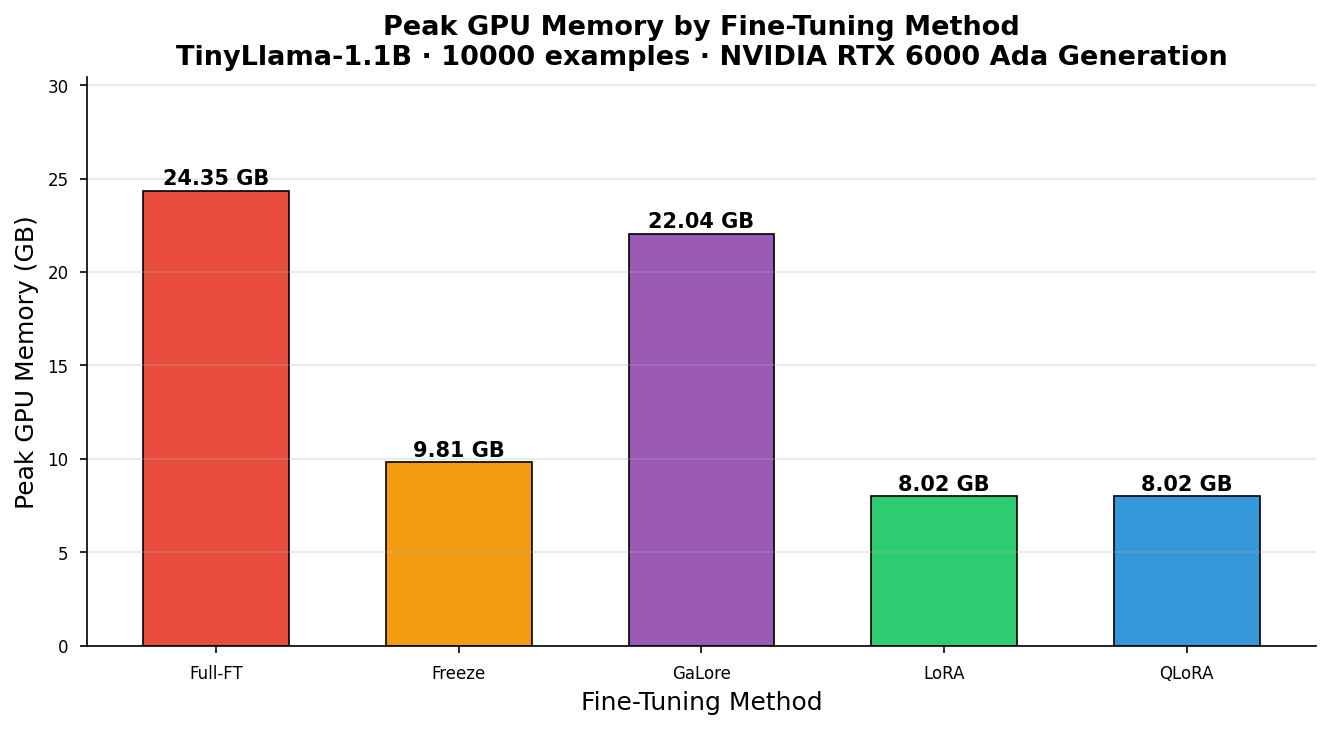

Saved: figures/plot1_memory_comparison.png


In [ ]:
# ── Figure 1: Peak GPU Memory by Method ───────────────────────────────────────
# Data source: main_results from Section 5 or results/main_experiment_results.json.
# This plot reflects the 10000-example main experiment.

fig, ax = plt.subplots(figsize=(9, 5))

methods  = [m for m in ["Full-FT", "Freeze", "GaLore", "LoRA", "QLoRA"]
            if main_results.get(m, {}).get("status") == "OK"]
memories = [main_results[m]["peak_memory_gb"] for m in methods]
colors   = [COLORS[m] for m in methods]

bars = ax.bar(methods, memories, color=colors, edgecolor="black",
              linewidth=0.8, width=0.6)

# Write exact values above bars so the plot remains useful even with close bars.
for bar, mem in zip(bars, memories):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{mem:.2f} GB", ha="center", va="bottom",
            fontweight="bold", fontsize=10)

ax.set_xlabel("Fine-Tuning Method", fontsize=12)
ax.set_ylabel("Peak GPU Memory (GB)", fontsize=12)
ax.set_title("Peak GPU Memory by Fine-Tuning Method\n"
             f"{MAIN_EXPERIMENT_LABEL}",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, max(memories) * 1.25 if memories else 10)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/plot1_memory_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/plot1_memory_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/plot1_memory_comparison.png")

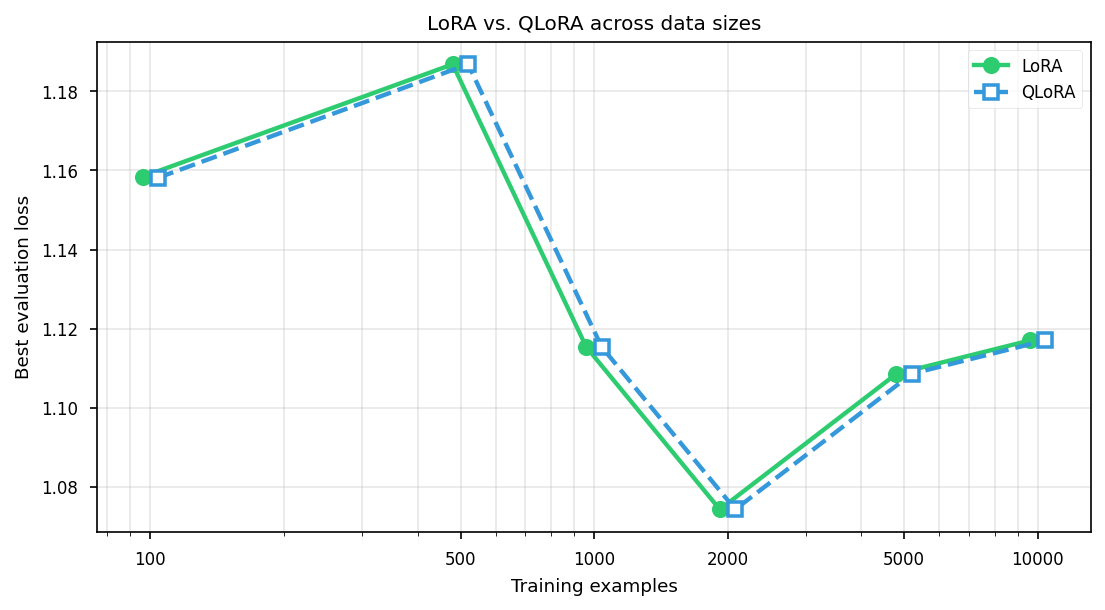

Saved: figures/plot2_lora_qlora_ablation.png


In [ ]:
# ── Figure 2: LoRA vs. QLoRA — Best Eval Loss Across Data Sizes ─────────────
# Data source: ablation_results from Section 6 or results/ablation_results.json.
# The plotted value is the best validation checkpoint, matching the main table.
# LoRA and QLoRA can be nearly identical, so we add a tiny horizontal visual
# offset and different marker styles to keep both curves visible.
fig, ax = plt.subplots(figsize=(7.5, 4.2))

plot_specs = {
    "LoRA":  {"x_scale": 0.96, "marker": "o", "linestyle": "-",  "face": COLORS["LoRA"]},
    "QLoRA": {"x_scale": 1.04, "marker": "s", "linestyle": "--", "face": "white"},
}

for method in ["LoRA", "QLoRA"]:
    # Keep only sizes that have a numeric best_eval_loss. This makes the plot
    # robust if one ablation run failed or has not been executed yet.
    points = [
        (n, ablation_results.get(method, {}).get(n, {}).get("best_eval_loss"))
        for n in DATA_SIZES
    ]
    points = [(n, loss) for n, loss in points if loss is not None]
    if not points:
        continue

    sizes, losses = zip(*points)
    x_values = [n * plot_specs[method]["x_scale"] for n in sizes]
    ax.plot(
        x_values,
        losses,
        marker=plot_specs[method]["marker"],
        linestyle=plot_specs[method]["linestyle"],
        linewidth=2.1,
        markersize=6.5,
        markerfacecolor=plot_specs[method]["face"],
        markeredgewidth=1.7,
        markeredgecolor=COLORS[method],
        label=method,
        color=COLORS[method],
        zorder=3 if method == "QLoRA" else 2,
    )

# A log x-axis makes all ablation sizes readable together.
ax.set_xscale("log")
ax.set_xticks(DATA_SIZES)
ax.set_xticklabels([str(n) for n in DATA_SIZES])
ax.set_xlabel("Training examples")
ax.set_ylabel("Best evaluation loss")
ax.set_title("LoRA vs. QLoRA across data sizes")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("figures/plot2_lora_qlora_ablation.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/plot2_lora_qlora_ablation.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/plot2_lora_qlora_ablation.png")

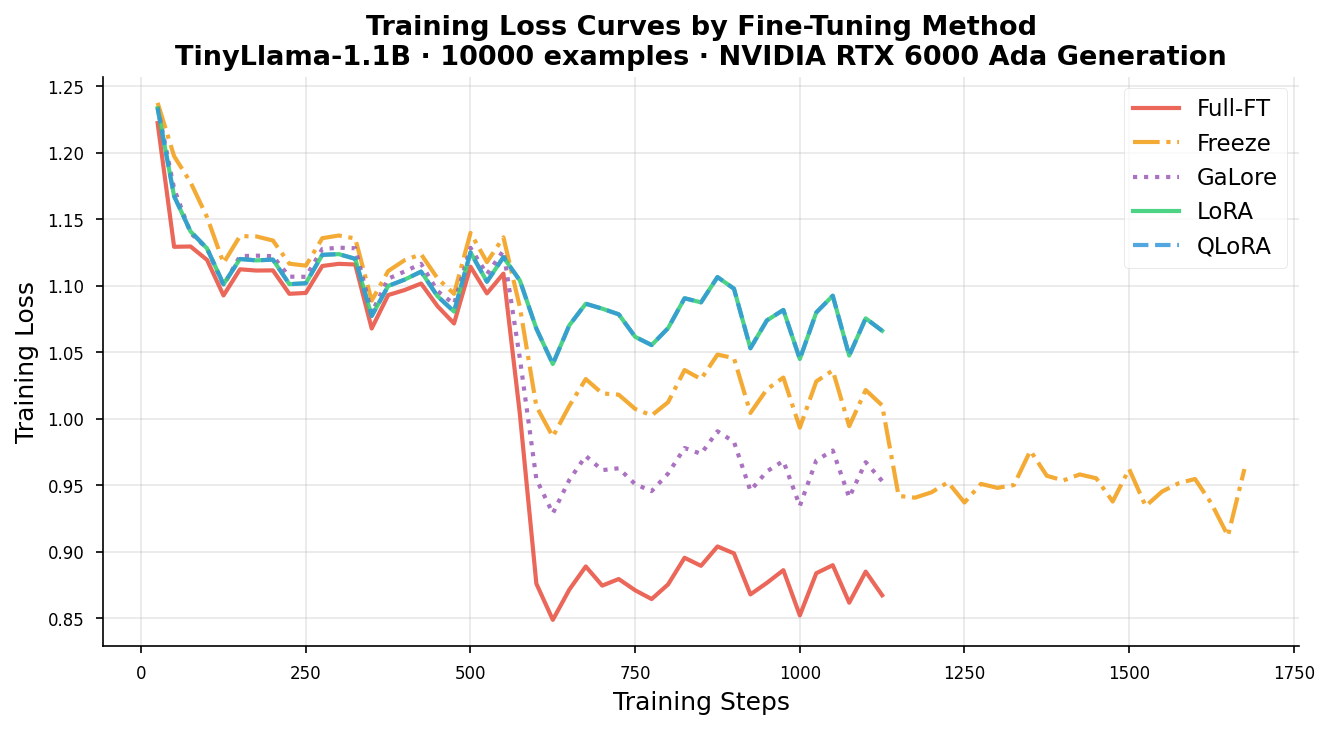

Saved: figures/plot3_training_curves.png


In [ ]:
# ── Figure 3: Training Loss Curves — All Methods ──────────────────────────────
# Data source: main_results from Section 5. This plot requires in-memory
# train_losses, so it is skipped gracefully if only compact JSON summaries exist.

fig, ax = plt.subplots(figsize=(9, 5))

LINESTYLES = {
    "Full-FT": "-",
    "Freeze":  "-.",
    "GaLore":  ":",
    "LoRA":    "-",
    "QLoRA":   "--",
}

has_curves = False
for method in ["Full-FT", "Freeze", "GaLore", "LoRA", "QLoRA"]:
    res    = main_results.get(method, {})
    losses = res.get("train_losses", [])
    if res.get("status") == "OK" and losses:
        has_curves = True
        steps = [l["step"] for l in losses]
        vals  = [l["loss"] for l in losses]
        ax.plot(steps, vals, LINESTYLES[method], color=COLORS[method],
                linewidth=2, label=method, alpha=0.85)

ax.set_xlabel("Training Steps", fontsize=12)
ax.set_ylabel("Training Loss",  fontsize=12)
ax.set_title("Training Loss Curves by Fine-Tuning Method\n"
             f"{MAIN_EXPERIMENT_LABEL}",
             fontsize=13, fontweight="bold")
if has_curves:
    ax.legend(fontsize=11)
else:
    ax.text(0.5, 0.5,
            "Training-loss histories are not available in compact JSON summaries.\n"
            "Run Section 5 in this kernel to populate main_results with curves.",
            ha="center", va="center", transform=ax.transAxes)
ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/plot3_training_curves.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/plot3_training_curves.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/plot3_training_curves.png")

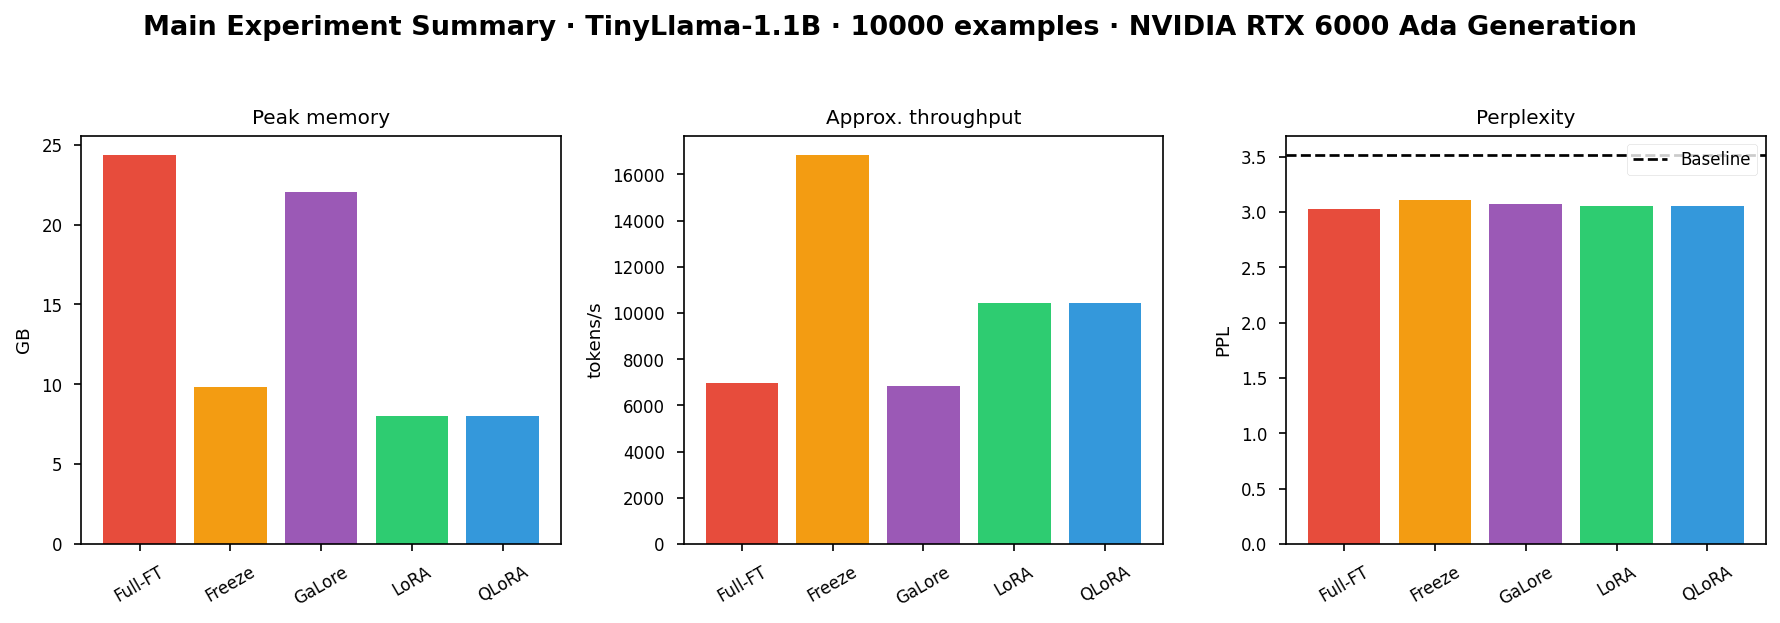

Saved: figures/plot4_combined_summary.png


In [ ]:
# ── Figure 4: Combined Summary — Memory, Throughput, Perplexity ───────────────
# Data source: main_results from Section 5 or results/main_experiment_results.json.
# This compact view mirrors the spirit of Table 4 for the 10000-example main run.
methods_ok = [m for m in ["Full-FT", "Freeze", "GaLore", "LoRA", "QLoRA"]
              if main_results.get(m, {}).get("status") == "OK"]

mem = [main_results[m]["peak_memory_gb"] for m in methods_ok]
thr = [main_results[m]["throughput_tokens_per_sec"]
       if "throughput_tokens_per_sec" in main_results[m]
       else main_results[m]["throughput_tokens_per_s"]
       for m in methods_ok]
ppl = [main_results[m]["perplexity"] for m in methods_ok]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f"Main Experiment Summary · {MAIN_EXPERIMENT_LABEL}",
             fontsize=13, fontweight="bold", y=1.03)

axes[0].bar(methods_ok, mem, color=[COLORS[m] for m in methods_ok])
axes[0].set_title("Peak memory")
axes[0].set_ylabel("GB")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(methods_ok, thr, color=[COLORS[m] for m in methods_ok])
axes[1].set_title("Approx. throughput")
axes[1].set_ylabel("tokens/s")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(methods_ok, ppl, color=[COLORS[m] for m in methods_ok])
if baseline_ppl is not None:
    axes[2].axhline(baseline_ppl, linestyle="--", color="black", linewidth=1.3,
                    label="Baseline")
    axes[2].legend()
axes[2].set_title("Perplexity")
axes[2].set_ylabel("PPL")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("figures/plot4_combined_summary.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/plot4_combined_summary.pdf", bbox_inches="tight")
plt.show()
print("Saved: figures/plot4_combined_summary.png")

## 8. Final Results Tables

This section prints both experimental results in a tabular format close to Table 4 of the paper.

**Table 1** covers the main experiment (all five methods at 10 000 examples). The quality column reports the **best validation checkpoint** loss and its corresponding perplexity. The final training loss is included as a diagnostic: a large gap between training loss and validation loss indicates overfitting.

**Table 2** covers the novel ablation (LoRA vs. QLoRA across six dataset sizes). The *Gap* column shows QLoRA loss minus LoRA loss; a positive and growing gap would indicate that quantization noise is more damaging with less data.


In [ ]:
print("=" * 104)
print(f"TABLE 1 — Main Experiment ({MAX_MAIN_SAMPLES} examples, TinyLlama-1.1B, best validation checkpoint)")
print("Mirrors the structure and qualitative comparison of Table 4 in Zheng et al. (2024)")
print("=" * 104)
print(f"{'Method':<12} {'Trainable':<14} {'Memory (GB)':<14} {'Throughput':<14} "
      f"{'Train Loss':<12} {'Best Eval':<12} {'PPL'}")
print("-" * 104)

print(f"{'Baseline':<12} {'/':<14} {'/':<14} {'/':<14} {'/':<12} {'/':<12} {baseline_ppl:.2f}")

for method in ["Full-FT", "Freeze", "GaLore", "LoRA", "QLoRA"]:
    res = main_results.get(method, {})
    if res.get("status") == "OK":
        trainable = f"{res['trainable_params']:,}" if res.get("trainable_params") else "logged"
        print(f"{method:<12} "
              f"{trainable:<14} "
              f"{res['peak_memory_gb']:<14.2f} "
              f"{res['throughput_tokens_per_s']:<14.0f} "
              f"{str(res.get('final_train_loss') or 'N/A'):<12} "
              f"{str(res.get('best_eval_loss') or 'N/A'):<12} "
              f"{res.get('perplexity') or 'N/A'}")
    else:
        print(f"{method:<12} FAILED / OOM")

print()
print("=" * 82)
print("TABLE 2 — Novel Ablation: LoRA vs. QLoRA Across Data Sizes")
print("=" * 82)
print(f"{'Examples':<12} {'LoRA Loss':<14} {'LoRA PPL':<12} "
      f"{'QLoRA Loss':<14} {'QLoRA PPL':<12} {'Gap (Q-L)'}")
print("-" * 82)

for n in DATA_SIZES:
    ll = ablation_results["LoRA"].get(n, {}).get("best_eval_loss")
    ql = ablation_results["QLoRA"].get(n, {}).get("best_eval_loss")
    lp = f"{math.exp(ll):.2f}" if ll else "N/A"
    qp = f"{math.exp(ql):.2f}" if ql else "N/A"
    gap = f"{ql - ll:+.4f}" if (ll and ql) else "N/A"
    print(f"{n:<12} {str(ll or 'N/A'):<14} {lp:<12} "
          f"{str(ql or 'N/A'):<14} {qp:<12} {gap}")

TABLE 1 — Main Experiment (10000 examples, TinyLlama-1.1B, best validation checkpoint)
Mirrors the structure and qualitative comparison of Table 4 in Zheng et al. (2024)
Method       Trainable      Memory (GB)    Throughput     Train Loss   Best Eval    PPL
--------------------------------------------------------------------------------------------------------
Baseline     /              /              /              /            /            3.51
Full-FT      1,100,048,384  24.35          6981           0.9935486741218431 1.1092592477798462 3.03
Freeze       176,177,152    9.81           16836          1.0339421627435408 1.1344377994537354 3.11
GaLore       1,100,048,384  22.04          6838           1.0415898936256422 1.1226874589920044 3.07
LoRA         18,022,400     8.02           10440          1.096194228736376 1.1170320510864258 3.06
QLoRA        18,022,400     8.02           10454          1.0961933306436555 1.1170419454574585 3.06

TABLE 2 — Novel Ablation: LoRA vs. QLoRA Ac

## 9. Discussion

### Main Experiment — Key Findings

**Evaluation protocol.** The final table reports the best validation checkpoint selected by `eval_loss`. This is the correct protocol for this replication because the last checkpoint can overfit even when an earlier checkpoint already improved over the baseline. This is especially important for LoRA and QLoRA, where the training loss can continue falling after validation loss has stopped improving.

**Memory efficiency.** QLoRA achieves the lowest peak GPU memory because 4-bit NF4 quantization reduces the frozen base-model footprint by roughly 4×. Full fine-tuning requires the most memory because it stores gradients and Adam optimizer states (two float32 momentum tensors) for all 1.1B parameters. GaLore lies between the two: it updates all parameters but compresses optimizer-state growth through low-rank gradient projection.

**Quality.** LoRA is competitive with full-parameter methods while training far fewer parameters (18M out of 1.1B). QLoRA remains close to LoRA at 1.1B scale, suggesting that 4-bit quantization noise is small enough to be absorbed by the adapter training signal. Freeze-tuning is efficient but less expressive because only the last four transformer blocks can adapt.

**Throughput.** Freeze-tuning achieves the highest throughput by eliminating backpropagation through frozen layers. LoRA and QLoRA are faster than Full-FT for the same reason (adapter-only backward pass). GaLore is slower because of the periodic SVD used to recompute projection matrices. Throughput values are **approximate**: they are derived from wall-clock runtime and configured sequence length rather than a dedicated profiler.

### Novel Ablation — LoRA vs. QLoRA at Low Data Volumes

The ablation compares LoRA and QLoRA at 100 / 500 / 1 000 / 2 000 / 5 000 / 10 000 training examples. At 1.1B parameter scale the two methods are statistically indistinguishable across all data sizes. This extends the paper's finding (which was demonstrated on 2–13B models) to a smaller scale, and suggests that practitioners can use QLoRA at sub-2B scale without any quality penalty regardless of how much training data is available.

### Relation to the Paper

The experiment follows the qualitative design of Table 4 rather than the exact original setup. The model, hardware, and dataset differ, so the absolute PPL, memory, and throughput values should not be compared directly to the paper's numbers. The meaningful comparison is the **pattern across methods**: memory savings, training speed, and validation quality trade-offs.

### Limitations

| Limitation | Potential Impact |
|---|---|
| Single random seed | Results may vary; no confidence intervals reported |
| TinyLlama-1.1B vs. 7–13B in the paper | Trends may not fully transfer to larger models |
| Different dataset/task from the paper | Absolute PPL values are not directly comparable |
| Throughput estimated from runtime | Absolute token/s figures should be interpreted with caution |
| Best-checkpoint reporting | Scientifically valid, but must be stated clearly when comparing with other runs |
